In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

sns.set_style("whitegrid")

In [14]:
# Load dataset
df = pd.read_csv("../Data/patients_clean.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (768, 11)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,diabetes_probability,risk_segment
0,6,148,72,35,125,33.6,0.627,50,1,0.698831,Medium_Risk
1,1,85,66,29,125,26.6,0.351,31,0,0.032494,Low_Risk
2,8,183,64,0,125,23.3,0.672,32,1,0.784301,High_Risk
3,1,89,66,23,94,28.1,0.167,21,0,0.036345,Low_Risk
4,0,137,40,35,168,43.1,2.288,33,1,0.847285,High_Risk


In [15]:
# Basic Data Check
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nOutcome distribution:\n", df["Outcome"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
 9   diabetes_probability      768 non-null    float64
 10  risk_segment              768 non-null    object 
dtypes: float64(3), int64(7), object(1)
memory usage: 66.1+ KB
None

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
Skin

In [16]:
# Feature/ Target split
X = df.drop(columns=["Outcome", "risk_segment"])
y = df["Outcome"]

In [17]:
# Train/ Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (614, 9)
Test size: (154, 9)


In [18]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [21]:
# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.7142857142857143

ROC AUC: 0.8138888888888889

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.83      0.79       100
           1       0.61      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



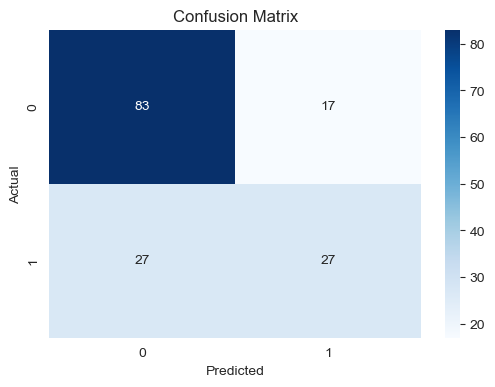

In [22]:
# Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

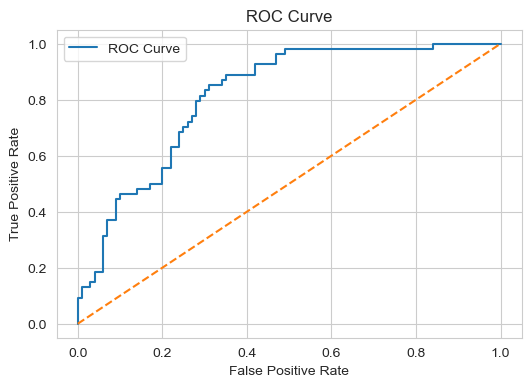

In [23]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

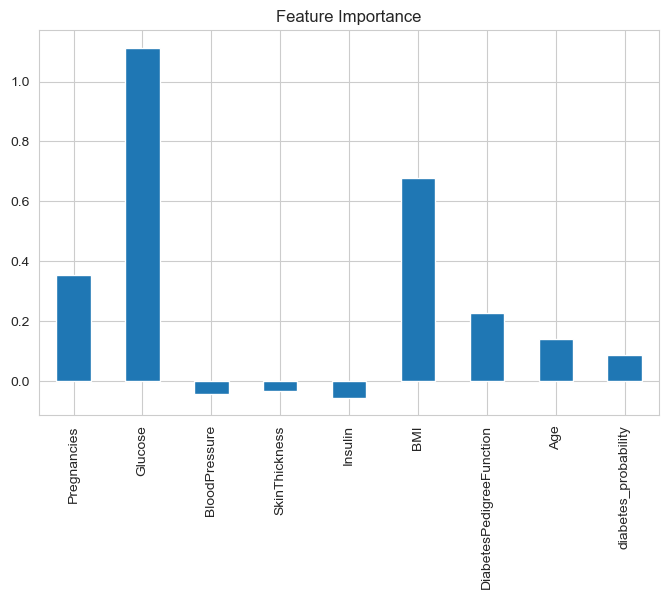

Pregnancies                 0.354943
Glucose                     1.113355
BloodPressure              -0.044381
SkinThickness              -0.032487
Insulin                    -0.055483
BMI                         0.676775
DiabetesPedigreeFunction    0.226718
Age                         0.139702
diabetes_probability        0.085846
dtype: float64

In [24]:
# Feature Importance (Logistic Regression Coefficients)
importance = pd.Series(model.coef_[0], index=X.columns)
iportance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

importance

In [26]:
# Add Predictions to dataset
df["model_probability"] = model.predict_proba(
    scaler.transform(df.drop(columns=["Outcome", "risk_segment"]))
)[:, 1]

df["model_prediction"] = (df["model_probability"] >= 0.5).astype(int)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,diabetes_probability,risk_segment,model_probability,model_prediction
0,6,148,72,35,125,33.6,0.627,50,1,0.698831,Medium_Risk,0.699520,1
1,1,85,66,29,125,26.6,0.351,31,0,0.032494,Low_Risk,0.035326,0
2,8,183,64,0,125,23.3,0.672,32,1,0.784301,High_Risk,0.782740,1
3,1,89,66,23,94,28.1,0.167,21,0,0.036345,Low_Risk,0.038458,0
4,0,137,40,35,168,43.1,2.288,33,1,0.847285,High_Risk,0.858987,1


In [27]:
# Export for Tableau
df.to_csv("../Data/diabetes_final_for_tableau.csv", index=False)
print("Exported successfully")

Exported successfully
